# NB5 v2 — Evaluation & Visualization (2-timestep / residual)

**Đồng bộ với nb4 v2**:
- Input layout mới: `[dyn_t, dyn_{t-1}, tb_t, tbmask_t, tb_{t-1}, tbmask_{t-1}, static]`
- Output chỉ có dynamic vars (không có lsm, geopotential_surf)
- Autoregressive rollout: dyn_{t-1} ← dyn_t (từ step trước); dyn_t ← prediction
- Multi-start RMSE averaged qua nhiều starting points
- Báo cáo RMSE theo đơn vị vật lý (Kelvin, Pa, m/s)


> **Tương thích nb4 bản tối ưu:** checkpoint mới có thêm 2 buffer không học (`m2m_deg`, `m2m_ea_zero`); cell load dùng `strict=False` để bỏ qua chúng. Kết quả inference không đổi (batch=1).

In [1]:
!pip install torch zarr xarray matplotlib cartopy scipy -q

In [2]:
import os, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial import cKDTree

# ── Paths ─────────────────────────────────────────────────────────
BASE_NB3 = "/kaggle/input/notebooks/phongngtun/nb3-2026"
BASE_NB4 = "/kaggle/input/notebooks/phongngtun/fork-of-nb4-grapcastmodel"   # ← đổi path này
OUT      = "/kaggle/working"

CKPT_PATH  = f"{BASE_NB4}/graphcast_sea_best.pt"
HIST_PATH  = f"{BASE_NB4}/training_history.json"
STATS_JSON = "/kaggle/input/notebooks/phongngtun/stat-compute/era5_normalization_stats.json"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {DEVICE}")

with open(STATS_JSON) as f:
    stats = json.load(f)
print(f"✓ Stats loaded: {len(stats)} variables")


✓ Device: cpu
✓ Stats loaded: 16 variables


## 5.1 Load Model (v2)

In [3]:
# ── Model class ────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=None, layers=2):
        super().__init__()
        hidden = hidden or out_dim
        net = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(layers - 2):
            net += [nn.Linear(hidden, hidden), nn.SiLU()]
        net += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*net)
        self.norm = nn.LayerNorm(out_dim)
    def forward(self, x):
        return self.norm(self.net(x))

class GNNLayer(nn.Module):
    def __init__(self, node_dim, edge_dim=1):
        super().__init__()
        self.msg_mlp  = MLP(node_dim * 2 + edge_dim, node_dim)
        self.node_mlp = MLP(node_dim * 2, node_dim)
    def forward(self, x, edge_src, edge_dst, edge_attr):
        src_feat = x[edge_src]
        dst_feat = x[edge_dst]
        msg = self.msg_mlp(torch.cat([src_feat, dst_feat, edge_attr], dim=-1))
        agg = torch.zeros_like(x)
        agg.scatter_add_(0, edge_dst.unsqueeze(1).expand_as(msg), msg)
        count = torch.zeros(x.size(0), 1, device=x.device)
        count.scatter_add_(0, edge_dst.unsqueeze(1),
                           torch.ones(msg.size(0), 1, device=x.device))
        agg = agg / (count + 1e-6)
        return x + self.node_mlp(torch.cat([x, agg], dim=-1))

class GraphCastSEA(nn.Module):
    def __init__(self, n_in, n_out, n_mesh, mesh_static_np, hidden=128, n_layers=4):
        super().__init__()
        self.n_mesh = n_mesh
        self.n_out  = n_out
        self.register_buffer('mesh_static', torch.from_numpy(mesh_static_np).float())
        self.grid_encoder = MLP(n_in, hidden)
        self.mesh_encoder = MLP(4,    hidden)
        self.g2m_mlp = MLP(hidden * 2 + 1, hidden)
        self.processors = nn.ModuleList([GNNLayer(hidden, 1) for _ in range(n_layers)])
        self.m2g_mlp = MLP(hidden * 2 + 1, hidden)
        self.decoder = nn.Linear(hidden, n_out)

    def forward(self, x_grid,
                g2m_src, g2m_dst, g2m_ea,
                m2m_src, m2m_dst,
                m2g_src, m2g_dst, m2g_ea):
        B = x_grid.size(0)
        device = x_grid.device
        residual_base = x_grid[..., :self.n_out]

        h_grid = self.grid_encoder(x_grid)
        h_mesh = self.mesh_encoder(self.mesh_static).unsqueeze(0).expand(B, -1, -1).contiguous()

        g_feat  = h_grid[:, g2m_src, :]
        m_feat  = h_mesh[:, g2m_dst, :]
        ea      = g2m_ea.unsqueeze(0).expand(B, -1, -1)
        msg_g2m = self.g2m_mlp(torch.cat([g_feat, m_feat, ea], dim=-1))
        agg     = torch.zeros(B, self.n_mesh, msg_g2m.size(-1), device=device)
        idx     = g2m_dst.unsqueeze(0).unsqueeze(-1).expand(B, -1, msg_g2m.size(-1))
        agg.scatter_add_(1, idx, msg_g2m)
        h_mesh  = h_mesh + agg

        m2m_ea_zero = torch.zeros(len(m2m_src), 1, device=device)
        for proc in self.processors:
            out_list = [proc(h_mesh[b], m2m_src, m2m_dst, m2m_ea_zero) for b in range(B)]
            h_mesh = torch.stack(out_list, dim=0)

        n_grid_ = h_grid.size(1)
        m_feat2 = h_mesh[:, m2g_src, :]
        g_feat2 = h_grid[:, m2g_dst, :]
        ea2     = m2g_ea.unsqueeze(0).expand(B, -1, -1)
        msg_m2g = self.m2g_mlp(torch.cat([m_feat2, g_feat2, ea2], dim=-1))
        agg2    = torch.zeros(B, n_grid_, msg_m2g.size(-1), device=device)
        idx2    = m2g_dst.unsqueeze(0).unsqueeze(-1).expand(B, -1, msg_m2g.size(-1))
        agg2.scatter_add_(1, idx2, msg_m2g)
        h_grid  = h_grid + agg2

        delta = self.decoder(h_grid)
        return residual_base + delta

# ── Load checkpoint ──────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
cfg  = ckpt['config']
print(f"  Epoch           : {ckpt['epoch']}")
print(f"  Best val loss   : {ckpt['val_loss']:.4f}")
print(f"  Persistence val : {ckpt.get('persistence_val', 'N/A')}")
print(f"  Dynamic vars    : {cfg['dynamic_vars']}")
print(f"  Static vars     : {cfg['static_vars']}")
print(f"  Residual        : {cfg.get('residual', False)}")

DYNAMIC_VARS = cfg['dynamic_vars']
STATIC_VARS  = cfg['static_vars']
mesh_static_np = ckpt['mesh_static_np']

model = GraphCastSEA(
    n_in=cfg['n_in'], n_out=cfg['n_out'], n_mesh=cfg['n_mesh'],
    mesh_static_np=mesh_static_np,
    hidden=cfg['hidden'], n_layers=cfg['n_layers'],
).to(DEVICE)
# strict=False: bỏ qua các buffer không học (m2m_deg / m2m_ea_zero) mà nb4 bản
# tối ưu lưu thêm vào checkpoint. Model ở nb5 tự tính lại degree trong forward
# nên các buffer đó không cần thiết — tham số học (MLP/encoder/decoder) khớp 100%.
missing, unexpected = model.load_state_dict(ckpt['model_state'], strict=False)
model.eval()
if unexpected:
    print(f"  (bỏ qua buffer thừa từ checkpoint: {list(unexpected)})")
if missing:
    print(f"  ⚠ thiếu key (cần kiểm tra): {list(missing)}")
assert not missing, "Thiếu tham số học — model class không khớp checkpoint!"
print(f"✓ Model loaded: {sum(p.numel() for p in model.parameters()):,} params")


  Epoch           : 50
  Best val loss   : 0.3522
  Persistence val : 0.5461069961116739
  Dynamic vars    : ['d2m', 'msl', 'q', 't2m', 'tp', 'u', 'u10', 'v', 'v10', 'z']
  Static vars     : ['lsm', 'geopotential_surf']
  Residual        : True
  (bỏ qua buffer thừa từ checkpoint: ['m2m_deg', 'm2m_ea_zero'])
✓ Model loaded: 538,382 params


## 5.2 Load Test Data + Rebuild Graph

In [4]:
TEST_YEAR = 2026

def find_zarr_path(folder_name):
    for root, dirs, _ in os.walk('/kaggle/input'):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    raise FileNotFoundError(f"❌ Không thấy {folder_name} — đã add output nb3-{TEST_YEAR} chưa?")

ds_test_x     = xr.open_zarr(find_zarr_path(f"brain_{TEST_YEAR}_x.zarr"),     consolidated=True)
ds_test_label = xr.open_zarr(find_zarr_path(f"brain_{TEST_YEAR}_label.zarr"), consolidated=True)
ds_eye_test   = xr.open_zarr(find_zarr_path(f"eye_{TEST_YEAR}_norm.zarr"),    consolidated=True)

lats = ds_test_x.lat.values
lons = ds_test_x.lon.values
n_grid = len(lats) * len(lons)
print(f"  Grid          : {len(lats)} × {len(lons)} = {n_grid}")
print(f"  Test samples  : {len(ds_test_x.time)}")

# ── Rebuild graph (giống nb4 v2) ──────────────────────────────────
MESH_RES = cfg['mesh_res']
mesh_lats_1d = np.arange(-10.0, 28.5, MESH_RES)
mesh_lons_1d = np.arange(92.0,  142.0, MESH_RES)
mlg, mnl = np.meshgrid(mesh_lats_1d, mesh_lons_1d, indexing='ij')
mesh_lats_flat = mlg.flatten()
mesh_lons_flat = mnl.flatten()

grid_lat_g, grid_lon_g = np.meshgrid(lats, lons, indexing='ij')
grid_pts = np.stack([grid_lat_g.flatten(), grid_lon_g.flatten()], axis=1)
mesh_pts = np.stack([mesh_lats_flat, mesh_lons_flat], axis=1)

tree = cKDTree(mesh_pts)
dists, indices = tree.query(grid_pts, k=4)
d_norm = (dists.flatten() - dists.mean()) / (dists.std() + 1e-6)

g2m_src = torch.tensor(np.repeat(np.arange(len(grid_pts)), 4), dtype=torch.long).to(DEVICE)
g2m_dst = torch.tensor(indices.flatten(), dtype=torch.long).to(DEVICE)
g2m_ea  = torch.tensor(d_norm, dtype=torch.float32).unsqueeze(1).to(DEVICE)

n_lat_m, n_lon_m = len(mesh_lats_1d), len(mesh_lons_1d)
m2m_s, m2m_d = [], []
for i in range(n_lat_m):
    for j in range(n_lon_m):
        node = i * n_lon_m + j
        for di in [-1,0,1]:
            for dj in [-1,0,1]:
                if di == 0 and dj == 0: continue
                ni, nj = i+di, j+dj
                if 0 <= ni < n_lat_m and 0 <= nj < n_lon_m:
                    m2m_s.append(node); m2m_d.append(ni*n_lon_m + nj)
m2m_src = torch.tensor(m2m_s, dtype=torch.long).to(DEVICE)
m2m_dst = torch.tensor(m2m_d, dtype=torch.long).to(DEVICE)

m2g_src = g2m_dst.clone()
m2g_dst = g2m_src.clone()
m2g_ea  = g2m_ea.clone()
print(f"  Graph: G→M {len(g2m_src):,} | M→M {len(m2m_src):,} | M→G {len(m2g_src):,}")


  Grid          : 159 × 201 = 31959
  Test samples  : 587
  Graph: G→M 127,836 | M→M 3,734 | M→G 127,836


## 5.3 Preload Test Arrays (Dynamic / Static / NASA)

In [5]:
# Expand channels
def expand_channels(var_list, ds):
    ch = []
    for v in var_list:
        if v not in ds.data_vars: continue
        da = ds[v]
        if 'pressure_level' in da.dims:
            for lev in da.pressure_level.values:
                ch.append((v, int(lev)))
        else:
            ch.append((v, None))
    return ch

dyn_channels  = expand_channels(DYNAMIC_VARS, ds_test_x)
stat_channels = expand_channels(STATIC_VARS,  ds_test_x)
N_DYN = len(dyn_channels)
print(f"  Dynamic channels ({N_DYN}): {dyn_channels}")
print(f"  Static  channels ({len(stat_channels)}): {stat_channels}")

def load_channels(ds, channels):
    arrs = []
    for v, lev in channels:
        da = ds[v]
        if lev is not None:
            da = da.sel(pressure_level=lev)
        arrs.append(da.values.reshape(len(da.time), -1))
    return np.stack(arrs, axis=2).astype(np.float32)

# Dynamic X and Y (test)
X_dyn_test = np.nan_to_num(load_channels(ds_test_x,     dyn_channels))
Y_dyn_test = np.nan_to_num(load_channels(ds_test_label, dyn_channels))

# Static ERA5 (time-invariant)
if stat_channels:
    stat_e5 = load_channels(ds_test_x.isel(time=slice(0,1)), stat_channels)[0]
else:
    stat_e5 = np.zeros((n_grid, 0), dtype=np.float32)

# Position static
lat_r = np.deg2rad(lats); lon_r = np.deg2rad(lons)
lat_g, lon_g = np.meshgrid(lat_r, lon_r, indexing='ij')
pos_static = np.stack([np.sin(lat_g), np.cos(lat_g),
                        np.sin(lon_g), np.cos(lon_g)], axis=-1
                      ).reshape(n_grid, 4).astype(np.float32)
static_all = np.nan_to_num(np.concatenate([stat_e5, pos_static], axis=1))

# NASA Tb + mask
tb_test = ds_eye_test['Tb'].values.reshape(len(ds_eye_test.time), -1, 1).astype(np.float32)
tb_mask = (~np.isnan(tb_test)).astype(np.float32)
tb_test = np.nan_to_num(tb_test, nan=0.0)

print(f"  X_dyn_test : {X_dyn_test.shape}")
print(f"  static_all : {static_all.shape}")
print(f"  tb_test    : {tb_test.shape}")


  Dynamic channels (14): [('d2m', None), ('msl', None), ('q', 850), ('q', 500), ('t2m', None), ('tp', None), ('u', 850), ('u', 500), ('u10', None), ('v', 850), ('v', 500), ('v10', None), ('z', 850), ('z', 500)]
  Static  channels (2): [('lsm', None), ('geopotential_surf', None)]
  X_dyn_test : (587, 31959, 14)
  static_all : (31959, 6)
  tb_test    : (587, 31959, 1)


## 5.4 Autoregressive Rollout + Multi-start RMSE

In [6]:
def assemble_input(dyn_t, dyn_tm1, tb_t, tbmask_t, tb_tm1, tbmask_tm1, static):
    """Ghép theo đúng layout nb4 v2. Trả về tensor (1, n_grid, n_in) trên DEVICE."""
    x = np.concatenate([dyn_t, dyn_tm1, tb_t, tbmask_t, tb_tm1, tbmask_tm1, static], axis=-1)
    return torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)


def rollout(start_idx, n_steps):
    """
    Rollout bắt đầu từ time index `start_idx` (start_idx >= 1 vì cần t-1).
    Trả về list predictions [(n_grid, N_DYN)] độ dài n_steps và list ground truth tương ứng.
    """
    dyn_t   = X_dyn_test[start_idx]
    dyn_tm1 = X_dyn_test[start_idx - 1]

    preds, gts = [], []
    with torch.no_grad():
        for step in range(n_steps):
            t_future = start_idx + step + 1
            if t_future >= len(X_dyn_test):
                break

            # NASA tại t và t-1 (dùng observation — không có leak forecast)
            tb_t      = tb_test[start_idx + step]
            tbmask_t  = tb_mask[start_idx + step]
            tb_tm1    = tb_test[start_idx + step - 1]
            tbmask_tm1= tb_mask[start_idx + step - 1]

            x = assemble_input(dyn_t, dyn_tm1,
                                tb_t, tbmask_t, tb_tm1, tbmask_tm1,
                                static_all)
            pred = model(x,
                         g2m_src, g2m_dst, g2m_ea,
                         m2m_src, m2m_dst,
                         m2g_src, m2g_dst, m2g_ea)
            pred_np = pred.squeeze(0).cpu().numpy()
            preds.append(pred_np)
            gts.append(Y_dyn_test[start_idx + step])   # Y_dyn_test[i] = state ở t+1 của ds_test_x[i]

            # Shift window: t-1 ← t, t ← pred
            dyn_tm1 = dyn_t
            dyn_t   = pred_np

    return preds, gts


# ── Multi-start evaluation ───────────────────────────────────────
N_STEPS    = 12          # +6h → +72h
N_STARTS   = 30          # số điểm xuất phát
MAX_START  = len(X_dyn_test) - N_STEPS - 1
start_indices = np.linspace(1, MAX_START, N_STARTS, dtype=int)
print(f"--- Multi-start rollout: {N_STARTS} starts × {N_STEPS} steps ---")

lat_weights_np = np.cos(np.deg2rad(lats))
lat_weights_np = lat_weights_np / lat_weights_np.mean()
lat_w = np.repeat(lat_weights_np, len(lons))

rmse_model   = np.zeros((N_STEPS, N_DYN))
rmse_persist = np.zeros((N_STEPS, N_DYN))
counts       = np.zeros(N_STEPS)

for si in start_indices:
    preds, gts = rollout(si, N_STEPS)
    persist_base = X_dyn_test[si]   # giá trị tại t, giữ nguyên
    for step, (p, g) in enumerate(zip(preds, gts)):
        for v in range(N_DYN):
            err_m = ((p[:, v] - g[:, v]) ** 2 * lat_w).mean()
            err_p = ((persist_base[:, v] - g[:, v]) ** 2 * lat_w).mean()
            rmse_model[step, v]   += err_m
            rmse_persist[step, v] += err_p
        counts[step] += 1

# Average
rmse_model   = np.sqrt(rmse_model   / counts[:, None])
rmse_persist = np.sqrt(rmse_persist / counts[:, None])

# In bảng
print(f"\n{'var':<25s}  {'+6h':>8s}  {'+24h':>8s}  {'+48h':>8s}  {'+72h':>8s}   (model / persist)")
for vi, (vname, lev) in enumerate(dyn_channels):
    key = f"{vname}" + (f"_{lev}hpa" if lev else "")
    tag = vname if lev is None else f"{vname}@{lev}hPa"
    row = ""
    for step in [0, 3, 7, 11]:
        if step < N_STEPS:
            m = rmse_model[step, vi]
            p = rmse_persist[step, vi]
            beats = "✓" if m < p else "✗"
            row += f"  {m:.3f}/{p:.3f}{beats}"
    print(f"  {tag:<25s}{row}")


--- Multi-start rollout: 30 starts × 12 steps ---

var                             +6h      +24h      +48h      +72h   (model / persist)
  d2m                        0.157/0.209✓  0.240/0.303✓  0.351/0.413✓  0.436/0.449✓
  msl                        0.154/0.473✓  0.310/0.382✓  0.519/0.625✓  0.634/0.705✓
  q@850hPa                   0.392/0.485✓  0.614/0.755✓  0.804/0.901✓  0.907/0.954✓
  q@500hPa                   0.306/0.366✓  0.513/0.648✓  0.667/0.780✓  0.793/0.859✓
  t2m                        0.177/0.619✓  0.242/0.275✓  0.328/0.345✓  0.386/0.376✗
  tp                         0.678/0.959✓  0.739/1.028✓  0.831/1.082✓  0.870/1.095✓
  u@850hPa                   0.251/0.308✓  0.451/0.543✓  0.611/0.705✓  0.710/0.783✓
  u@500hPa                   0.195/0.231✓  0.377/0.449✓  0.502/0.595✓  0.555/0.658✓
  u10                        0.288/0.368✓  0.461/0.542✓  0.617/0.708✓  0.698/0.758✓
  v@850hPa                   0.371/0.492✓  0.638/0.826✓  0.824/1.036✓  0.923/1.133✓
  v@500hPa             

## 5.5 RMSE vs Lead Time — Vật lý Unit

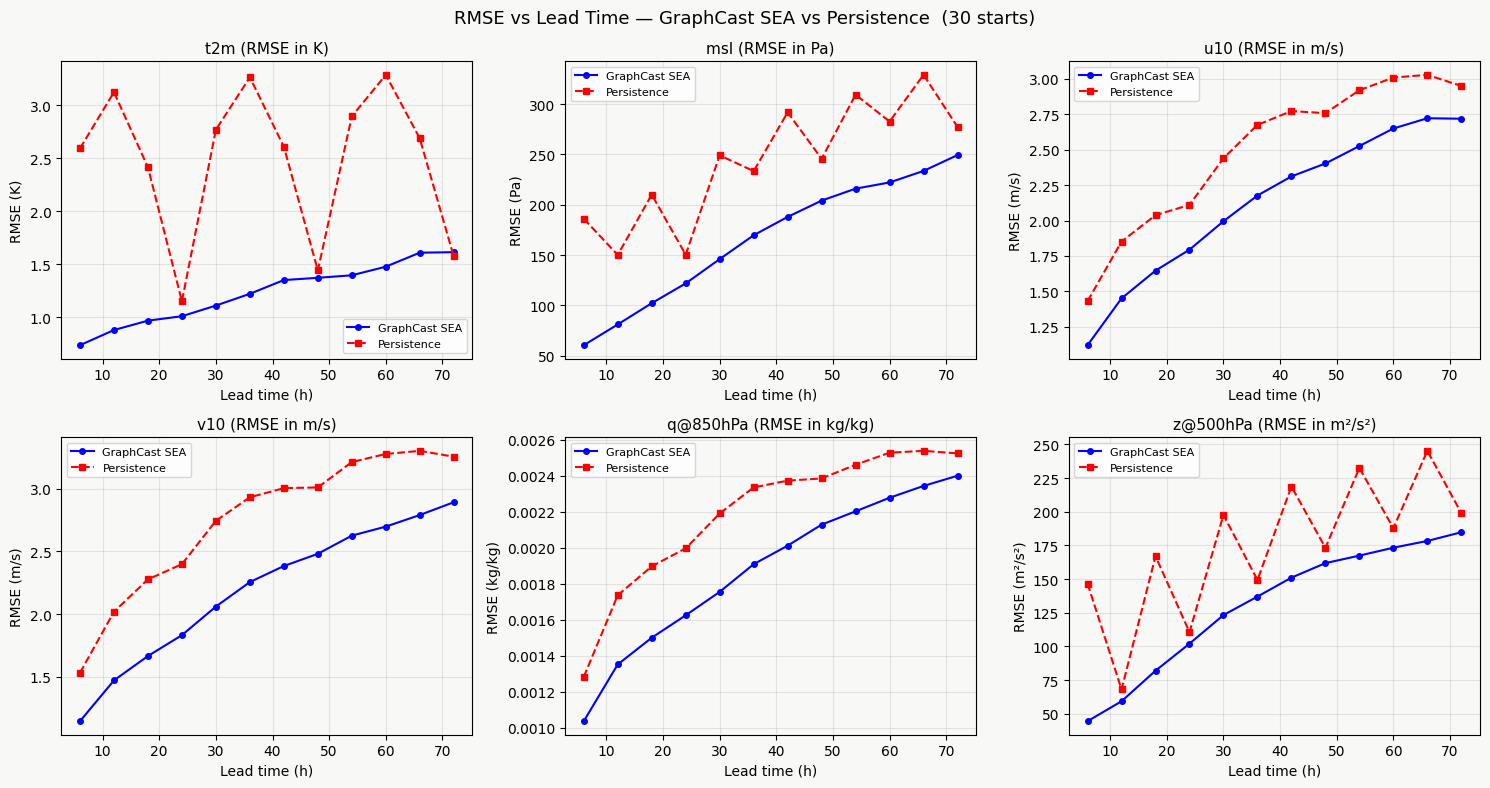

✓ Saved: rmse_lead_time_v2.png, rmse_summary_v2.json


In [7]:
# Denormalize RMSE về đơn vị vật lý
# Note: RMSE trong không gian normalized × std = RMSE gốc (vì mean cancel)
def get_std(var, lev):
    key = var if lev is None else f"{var}_{lev}hpa"
    if key in stats:
        return stats[key]['std']
    for k in stats:
        if k.startswith(var):
            return stats[k]['std']
    return 1.0

stds = np.array([get_std(v, l) for v, l in dyn_channels])   # (N_DYN,)

rmse_model_phys   = rmse_model   * stds[None, :]
rmse_persist_phys = rmse_persist * stds[None, :]

# Plot cho một vài biến quan trọng
lead_times = np.arange(1, N_STEPS + 1) * 6
IMPORTANT = [('t2m', None, 'K'), ('msl', None, 'Pa'),
             ('u10', None, 'm/s'), ('v10', None, 'm/s'),
             ('q', 850, 'kg/kg'), ('z', 500, 'm²/s²')]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax_i, (var, lev, unit) in enumerate(IMPORTANT):
    target = (var, lev)
    if target not in dyn_channels:
        axes[ax_i].set_visible(False); continue
    vi = dyn_channels.index(target)
    ax = axes[ax_i]
    ax.plot(lead_times, rmse_model_phys[:, vi],   'b-o', label='GraphCast SEA', markersize=4)
    ax.plot(lead_times, rmse_persist_phys[:, vi], 'r--s', label='Persistence',  markersize=4)
    title = var if lev is None else f"{var}@{lev}hPa"
    ax.set_title(f"{title} (RMSE in {unit})", fontsize=11)
    ax.set_xlabel('Lead time (h)')
    ax.set_ylabel(f'RMSE ({unit})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_facecolor('#f8f8f6')

fig.patch.set_facecolor('#f8f8f6')
plt.suptitle(f'RMSE vs Lead Time — GraphCast SEA vs Persistence  ({N_STARTS} starts)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT}/rmse_lead_time_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Save summary table
summary = {
    'lead_hours': lead_times.tolist(),
    'n_starts': int(N_STARTS),
    'channels': [{'var': v, 'level': l} for v, l in dyn_channels],
    'rmse_model_normalized'  : rmse_model.tolist(),
    'rmse_persist_normalized': rmse_persist.tolist(),
    'rmse_model_physical'    : rmse_model_phys.tolist(),
    'rmse_persist_physical'  : rmse_persist_phys.tolist(),
}
with open(f'{OUT}/rmse_summary_v2.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Saved: rmse_lead_time_v2.png, rmse_summary_v2.json")


## 5.5b Metrics nâng cao — ACC & RMSE phân vùng

--- ACC + Regional RMSE: 30 starts × 12 steps ---

ACC (1.0 = hoàn hảo; ~0.6 = ngưỡng có kỹ năng)
  var                  + 6h  +24h  +48h  +72h
  d2m                  0.965  0.921  0.830  0.741
  msl                  0.981  0.918  0.768  0.654
  q@850                0.891  0.722  0.566  0.497
  q@500                0.922  0.768  0.638  0.545
  t2m                  0.958  0.929  0.869  0.820
  tp                   0.543  0.363  0.251  0.184
  u@850                0.952  0.835  0.693  0.592
  u@500                0.952  0.814  0.644  0.528
  u10                  0.936  0.821  0.676  0.589
  v@850                0.907  0.698  0.462  0.309
  v@500                0.890  0.551  0.190  0.067
  v10                  0.922  0.789  0.583  0.429
  z@850                0.972  0.874  0.660  0.529
  z@500                0.980  0.903  0.763  0.672

RMSE phân vùng (đơn vị vật lý):
  t2m (K): +24h | +72h
      Toàn miền        1.011  1.615
      Đất liền         1.574  2.556
      Biển             0.716

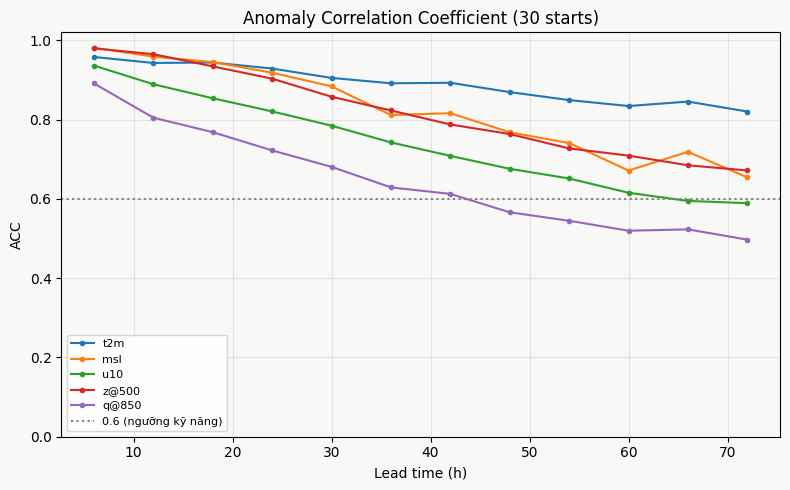

✓ Saved: acc_lead_time.png


In [8]:
# Một vòng multi-start rollout, tích luỹ ACC + RMSE phân vùng cùng lúc.
# Climatology = trường trung bình theo thời gian trên tập test (không gian chuẩn hoá).
clim = Y_dyn_test.mean(axis=0)                      # (n_grid, N_DYN)

# Mặt nạ vùng từ static (denorm về đơn vị gốc)
stat_names = [v for (v, lev) in stat_channels]
def _denorm_static(name):
    col = stat_names.index(name)
    return static_all[:, col] * stats[name]['std'] + stats[name]['mean']

masks = {'Toàn miền': np.ones(n_grid, dtype=bool)}
if 'lsm' in stat_names:
    lsm_raw = _denorm_static('lsm')
    masks['Đất liền'] = lsm_raw > 0.5
    masks['Biển']     = lsm_raw <= 0.5
if 'geopotential_surf' in stat_names:
    elev = _denorm_static('geopotential_surf') / 9.80665     # geopotential → cao độ (m)
    land = masks.get('Đất liền', np.ones(n_grid, dtype=bool))
    thr  = np.quantile(elev[land], 0.75) if land.any() else np.quantile(elev, 0.75)
    masks['Núi (≥Q75)']  = land & (elev >= thr)
    masks['Đồng bằng']   = land & (elev <  thr)
wcount = {m: float(lat_w[masks[m]].sum()) for m in masks}

REG_VARS  = [('t2m', None, 'K'), ('msl', None, 'Pa'), ('z', 500, 'm²/s²')]
REG_STEPS = [s for s in [3, 11] if s < N_STEPS]      # +24h, +72h

acc_num = np.zeros((N_STEPS, N_DYN)); acc_df = np.zeros((N_STEPS, N_DYN)); acc_do = np.zeros((N_STEPS, N_DYN))
sse = {m: {(v, l): {s: 0.0 for s in REG_STEPS} for v, l, _ in REG_VARS} for m in masks}
n_acc = np.zeros(N_STEPS); n_reg = {s: 0 for s in REG_STEPS}

print(f"--- ACC + Regional RMSE: {N_STARTS} starts × {N_STEPS} steps ---")
for si in start_indices:
    preds, gts = rollout(si, N_STEPS)
    w = lat_w[:, None]
    for step, (p, g) in enumerate(zip(preds, gts)):
        fa, oa = p - clim, g - clim
        acc_num[step] += (w * fa * oa).sum(axis=0)
        acc_df[step]  += (w * fa * fa).sum(axis=0)
        acc_do[step]  += (w * oa * oa).sum(axis=0)
        n_acc[step] += 1
        if step in REG_STEPS:
            for v, l, _ in REG_VARS:
                if (v, l) not in dyn_channels: continue
                vi = dyn_channels.index((v, l)); sd = stds[vi]
                err2 = ((p[:, vi] - g[:, vi]) * sd) ** 2 * lat_w     # physical, lat-weighted
                for m, mask in masks.items():
                    sse[m][(v, l)][step] += err2[mask].sum()
            n_reg[step] += 1

acc = acc_num / (np.sqrt(acc_df * acc_do) + 1e-12)
lead_times = np.arange(1, N_STEPS + 1) * 6

# Bảng ACC
print(f"\nACC (1.0 = hoàn hảo; ~0.6 = ngưỡng có kỹ năng)")
print(f"  {'var':<20s} " + "  ".join(f"+{lead_times[s]:>2}h" for s in [0,3,7,11] if s < N_STEPS))
for vi, (vn, lev) in enumerate(dyn_channels):
    tag = vn if lev is None else f"{vn}@{lev}"
    print(f"  {tag:<20s} " + "  ".join(f"{acc[s,vi]:.3f}" for s in [0,3,7,11] if s < N_STEPS))

# Bảng RMSE phân vùng
print(f"\nRMSE phân vùng (đơn vị vật lý):")
for v, l, unit in REG_VARS:
    if (v, l) not in dyn_channels: continue
    tag = v if l is None else f"{v}@{l}"
    print(f"  {tag} ({unit}): " + " | ".join(f"+{(s+1)*6}h" for s in REG_STEPS))
    for m in masks:
        cells = []
        for s in REG_STEPS:
            denom = wcount[m] * n_reg[s] + 1e-12
            cells.append(f"{np.sqrt(sse[m][(v,l)][s]/denom):.3f}")
        print(f"      {m:<16s} " + "  ".join(cells))

# Plot ACC
plt.figure(figsize=(8, 5))
for vn, lev in [('t2m', None), ('msl', None), ('u10', None), ('z', 500), ('q', 850)]:
    if (vn, lev) in dyn_channels:
        vi = dyn_channels.index((vn, lev))
        plt.plot(lead_times, acc[:, vi], '-o', ms=3, label=(vn if lev is None else f"{vn}@{lev}"))
plt.axhline(0.6, ls=':', color='gray', label='0.6 (ngưỡng kỹ năng)')
plt.xlabel('Lead time (h)'); plt.ylabel('ACC'); plt.ylim(0, 1.02)
plt.title(f'Anomaly Correlation Coefficient ({N_STARTS} starts)')
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.gca().set_facecolor('#f8f8f6'); plt.gcf().patch.set_facecolor('#f8f8f6')
plt.tight_layout(); plt.savefig(f'{OUT}/acc_lead_time.png', dpi=150, bbox_inches='tight'); plt.show()
print("✓ Saved: acc_lead_time.png")


## 5.6 Forecast Map (t2m example)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


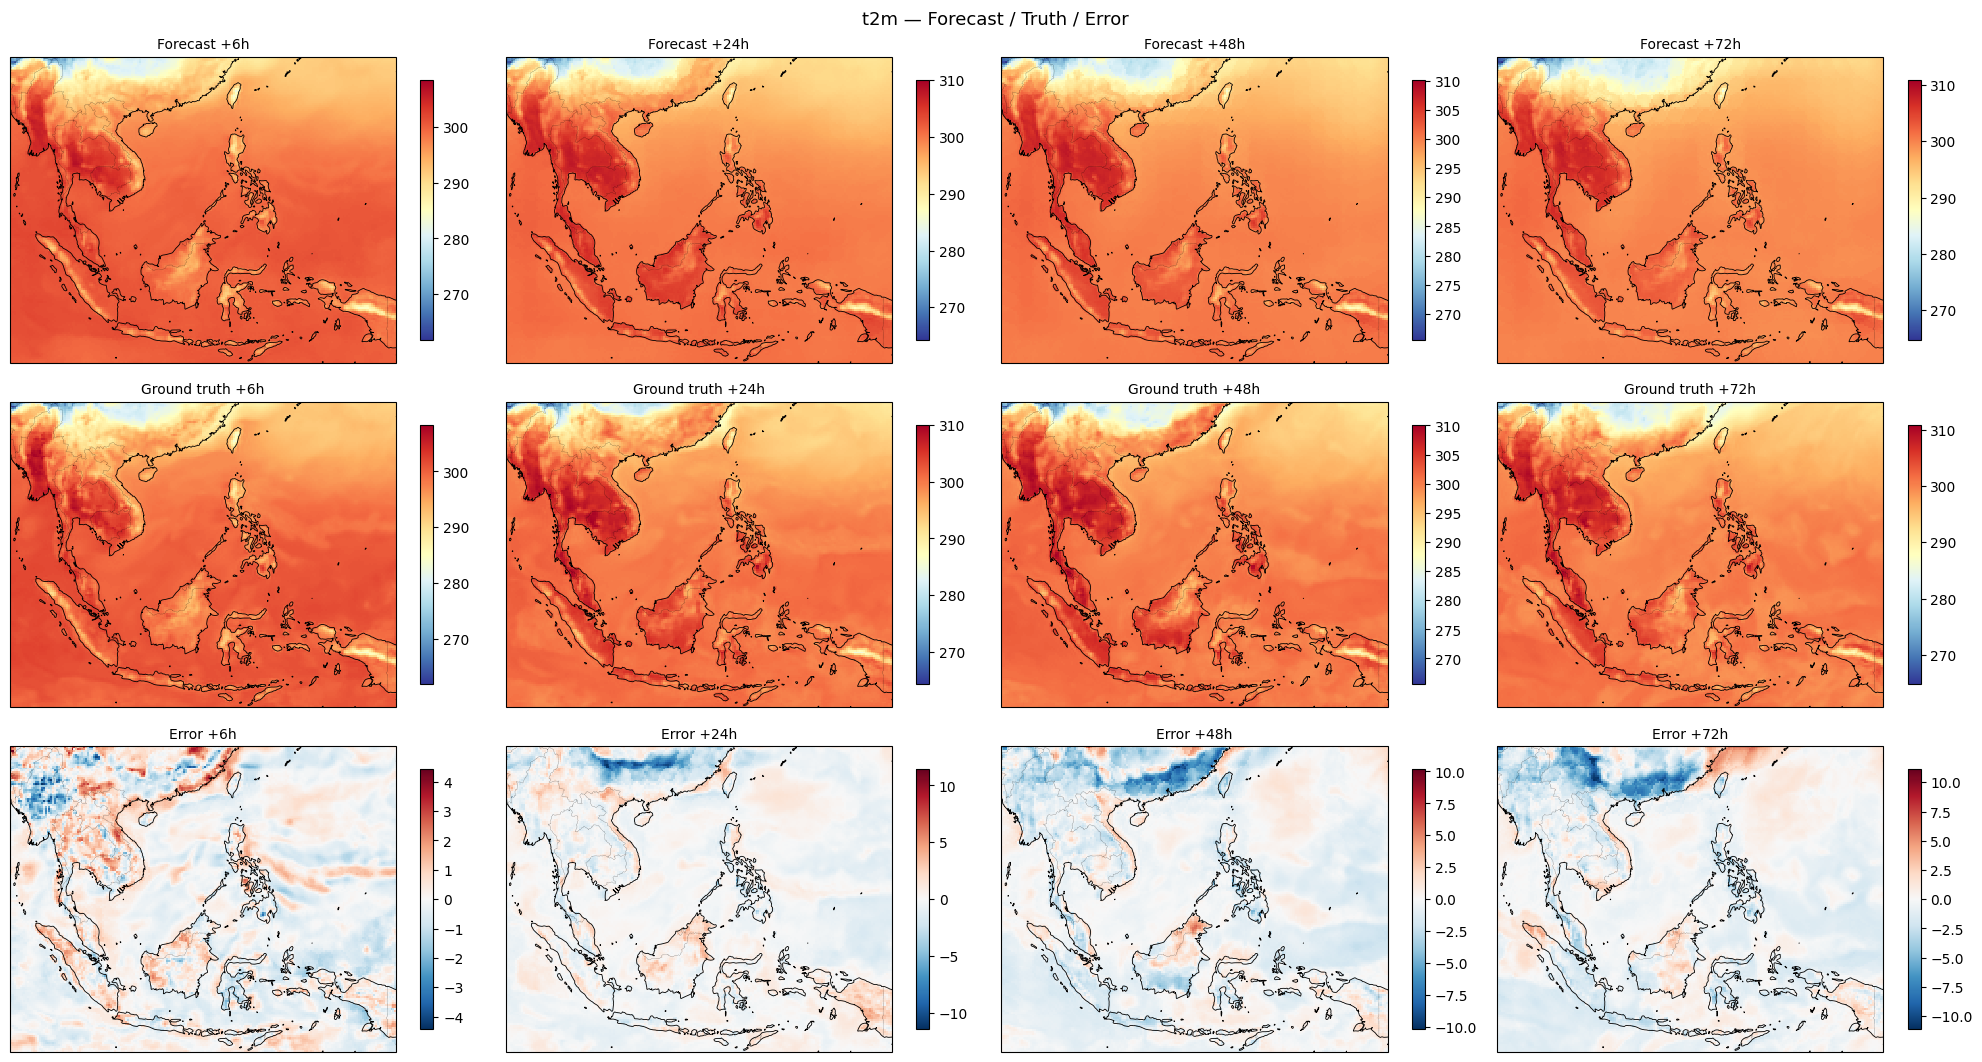

✓ Saved: forecast_map_t2m_v2.png


In [9]:
# Rollout từ 1 start cho forecast map visualization
TEST_START = start_indices[len(start_indices) // 2]   # lấy điểm giữa
preds_viz, gts_viz = rollout(TEST_START, N_STEPS)

PLOT_TARGET = ('t2m', None)
if PLOT_TARGET not in dyn_channels:
    PLOT_TARGET = dyn_channels[0]
vi = dyn_channels.index(PLOT_TARGET)
var_name, lev = PLOT_TARGET
var_tag = var_name if lev is None else f"{var_name}@{lev}hPa"

# Denorm: arr * std + mean
def denorm_map(arr_1d, var, lev):
    key = var if lev is None else f"{var}_{lev}hpa"
    if key not in stats:
        for k in stats:
            if k.startswith(var):
                key = k; break
    m = stats[key]['mean']; s = stats[key]['std']
    return arr_1d * s + m

STEPS_TO_PLOT = [0, 3, 7, 11]   # +6h, +24h, +48h, +72h
fig, axes = plt.subplots(3, len(STEPS_TO_PLOT),
                          figsize=(5 * len(STEPS_TO_PLOT), 11),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for col, step in enumerate(STEPS_TO_PLOT):
    if step >= len(preds_viz): continue
    lead_h = (step + 1) * 6

    pred_phys = denorm_map(preds_viz[step][:, vi], var_name, lev).reshape(len(lats), len(lons))
    gt_phys   = denorm_map(gts_viz[step][:, vi],   var_name, lev).reshape(len(lats), len(lons))
    err       = pred_phys - gt_phys

    vmin = min(pred_phys.min(), gt_phys.min())
    vmax = max(pred_phys.max(), gt_phys.max())
    err_max = max(abs(err.min()), abs(err.max()))

    for row, (data, title, cmap, vlo, vhi) in enumerate([
        (pred_phys, f'Forecast +{lead_h}h',  'RdYlBu_r', vmin, vmax),
        (gt_phys,   f'Ground truth +{lead_h}h', 'RdYlBu_r', vmin, vmax),
        (err,       f'Error +{lead_h}h', 'RdBu_r', -err_max, err_max),
    ]):
        ax = axes[row][col]
        im = ax.pcolormesh(lons, lats, data, cmap=cmap, vmin=vlo, vmax=vhi,
                            transform=ccrs.PlateCarree(), shading='auto')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':')
        ax.set_title(title, fontsize=10)
        plt.colorbar(im, ax=ax, shrink=0.75)

plt.suptitle(f'{var_tag} — Forecast / Truth / Error', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT}/forecast_map_{var_name}_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: forecast_map_{var_name}_v2.png")


## 5.6b Phân tích phổ (kiểm tra mờ hóa)

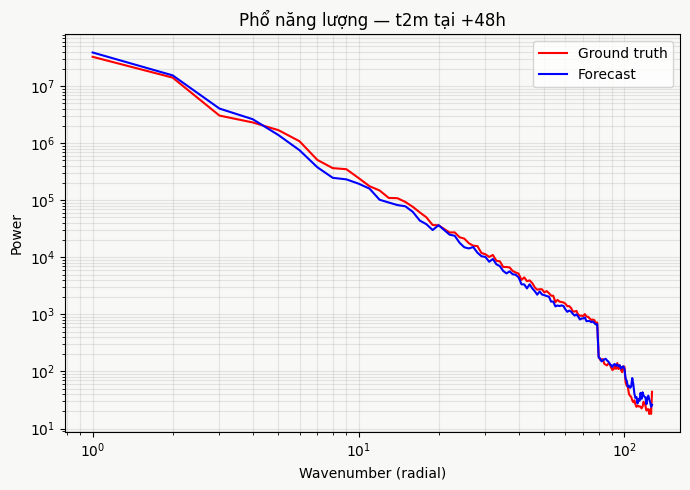

✓ Saved: spectrum_t2m.png — forecast dưới truth ở k cao = bị mờ hoá.


In [10]:
# Phổ năng lượng theo wavenumber: forecast vs ground truth.
# Forecast tụt dưới truth ở wavenumber cao ⇒ mô hình làm mờ chi tiết quy mô nhỏ.
def radial_spectrum(field2d):
    F = np.fft.fftshift(np.fft.fft2(field2d - field2d.mean()))
    P = np.abs(F) ** 2
    ny, nx = field2d.shape
    y, x = np.indices((ny, nx))
    r = np.sqrt((x - nx // 2) ** 2 + (y - ny // 2) ** 2).astype(int)
    tbin = np.bincount(r.ravel(), P.ravel())
    nbin = np.bincount(r.ravel())
    return tbin / np.maximum(nbin, 1)

SPEC_VAR  = ('t2m', None) if ('t2m', None) in dyn_channels else dyn_channels[0]
svi       = dyn_channels.index(SPEC_VAR)
SPEC_STEP = min(7, len(preds_viz) - 1)                 # ~+48h
pf = preds_viz[SPEC_STEP][:, svi].reshape(len(lats), len(lons))
gf = gts_viz[SPEC_STEP][:, svi].reshape(len(lats), len(lons))
sp_f, sp_g = radial_spectrum(pf), radial_spectrum(gf)
k = np.arange(1, len(sp_g))

plt.figure(figsize=(7, 5))
plt.loglog(k, sp_g[1:], 'r-', label='Ground truth')
plt.loglog(k, sp_f[1:], 'b-', label='Forecast')
plt.xlabel('Wavenumber (radial)'); plt.ylabel('Power')
tag = SPEC_VAR[0] if SPEC_VAR[1] is None else f"{SPEC_VAR[0]}@{SPEC_VAR[1]}"
plt.title(f'Phổ năng lượng — {tag} tại +{(SPEC_STEP+1)*6}h')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.gca().set_facecolor('#f8f8f6'); plt.gcf().patch.set_facecolor('#f8f8f6')
plt.tight_layout(); plt.savefig(f'{OUT}/spectrum_{tag}.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"✓ Saved: spectrum_{tag}.png — forecast dưới truth ở k cao = bị mờ hoá.")


## 5.7 Training Curve + Summary

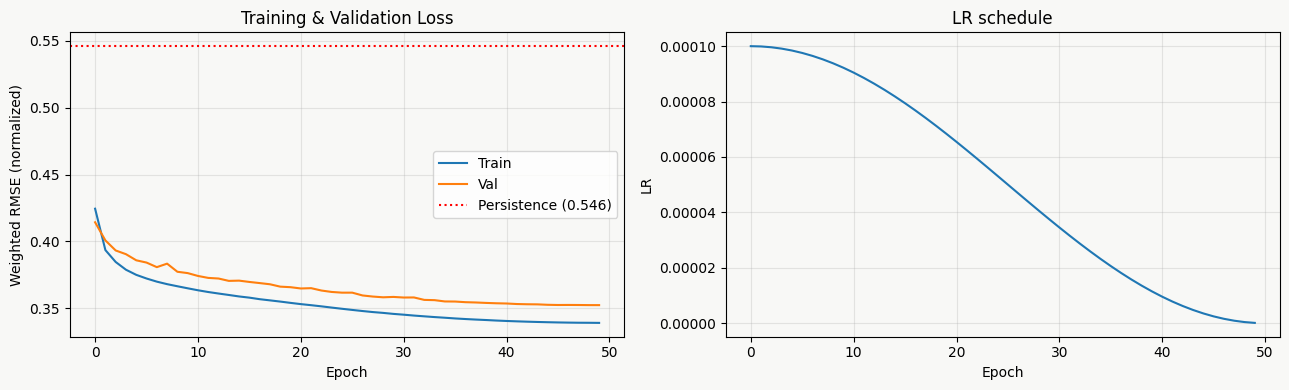


SUMMARY v2
Model params     : 538,382
Best val loss    : 0.3522
Persistence val  : 0.5461069961116739
Improvement      : +35.5% vs persistence
Dynamic vars     : ['d2m', 'msl', 'q', 't2m', 'tp', 'u', 'u10', 'v', 'v10', 'z']
Static vars      : ['lsm', 'geopotential_surf']

t2m RMSE (K):
  + 6h : model=0.739  persist=2.591
  +24h : model=1.011  persist=1.152
  +48h : model=1.373  persist=1.442
  +72h : model=1.615  persist=1.574


In [11]:
if os.path.exists(HIST_PATH):
    with open(HIST_PATH) as f:
        history = json.load(f)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    if 'persistence_val' in history:
        axes[0].axhline(history['persistence_val'], ls=':', color='red',
                        label=f"Persistence ({history['persistence_val']:.3f})")
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted RMSE (normalized)')
    axes[0].set_title('Training & Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['lr'])
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR'); axes[1].set_title('LR schedule')
    axes[1].grid(alpha=0.3)

    for ax in axes: ax.set_facecolor('#f8f8f6')
    fig.patch.set_facecolor('#f8f8f6')
    plt.tight_layout()
    plt.savefig(f'{OUT}/training_curve_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

# Summary
print("\n" + "="*60)
print("SUMMARY v2")
print("="*60)
print(f"Model params     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Best val loss    : {ckpt['val_loss']:.4f}")
print(f"Persistence val  : {ckpt.get('persistence_val', 'N/A')}")
if 'persistence_val' in ckpt:
    imp = (1 - ckpt['val_loss'] / ckpt['persistence_val']) * 100
    print(f"Improvement      : {imp:+.1f}% vs persistence")
print(f"Dynamic vars     : {DYNAMIC_VARS}")
print(f"Static vars      : {STATIC_VARS}")

# t2m specific
if ('t2m', None) in dyn_channels:
    vi = dyn_channels.index(('t2m', None))
    print(f"\nt2m RMSE (K):")
    for step in [0, 3, 7, 11]:
        if step < N_STEPS:
            print(f"  +{(step+1)*6:>2}h : model={rmse_model_phys[step, vi]:.3f}  "
                  f"persist={rmse_persist_phys[step, vi]:.3f}")


## 5.7 So sánh baseline U-Net (cùng test, cùng rollout)

✓ U-Net loaded: 4,350,686 params (val=0.2966362617787768)

var                lead   GNN      U-Net    Clima    Persist   thắng
  d2m              +24h    1.051    0.911    2.692    1.329   U-Net
  d2m              +72h    1.911    1.701    2.778    1.969   U-Net
  msl              +24h  121.824  108.124  307.323  150.333   U-Net
  msl              +72h  249.413  229.594  315.927  277.373   U-Net
  q@850            +24h    0.002    0.001    0.002    0.002   U-Net
  q@850            +72h    0.002    0.002    0.002    0.003   U-Net
  q@500            +24h    0.001    0.001    0.001    0.001   U-Net
  q@500            +72h    0.001    0.001    0.001    0.001   U-Net
  t2m              +24h    1.011    0.927    2.726    1.152   U-Net
  t2m              +72h    1.615    1.516    2.757    1.574   U-Net
  tp               +24h    0.001    0.001    0.001    0.001   U-Net
  tp               +72h    0.001    0.001    0.001    0.001   Clima
  u@850            +24h    2.675    2.218    4.850    3.

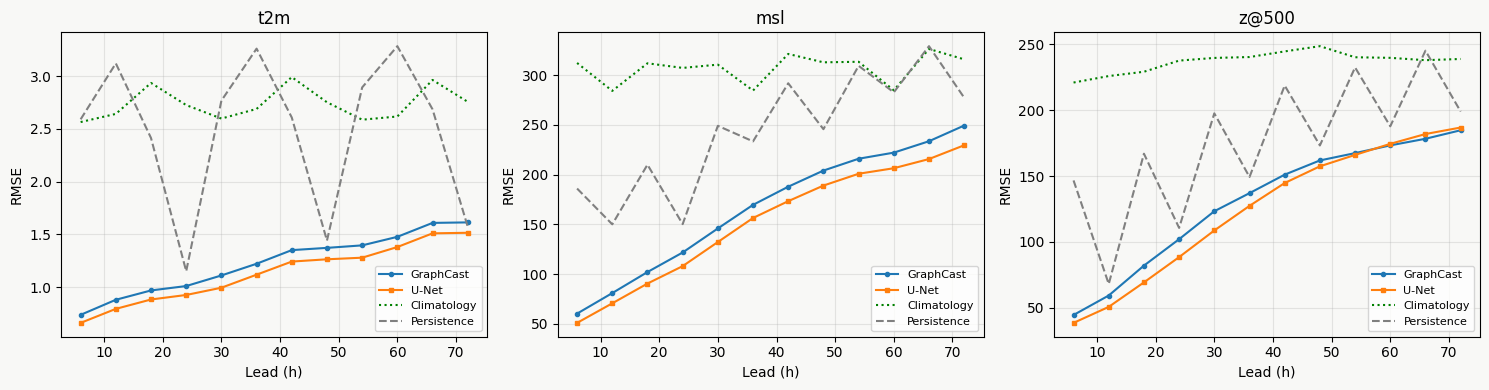

✓ Saved: compare_gnn_unet.png + .json


In [12]:
# ── U-Net baseline: dựng lại + load checkpoint ───────────────────
import torch.nn.functional as F
torch.backends.cudnn.benchmark = False     # tránh lỗi cuDNN 'FIND ... no engine' với conv

def find_file(name):
    for root, _, files in os.walk('/kaggle/input'):
        if name in files:
            return os.path.join(root, name)
    raise FileNotFoundError(f"❌ Không thấy {name} — đã add output nb4b (U-Net) vào input chưa?")

UNET_CKPT = find_file('unet_baseline_best.pt')
uck = torch.load(UNET_CKPT, map_location=DEVICE, weights_only=False)
ucfg = uck['config']
assert ucfg.get('model_type') == 'unet', "Checkpoint không phải U-Net"

class DoubleConv(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.GroupNorm(8, cout), nn.SiLU(),
            nn.Conv2d(cout, cout, 3, padding=1), nn.GroupNorm(8, cout), nn.SiLU())
    def forward(self, x): return self.net(x)

class UNetSEA(nn.Module):
    def __init__(self, n_in, n_out, H, W, base=48, depth=3):
        super().__init__()
        self.n_in, self.n_out, self.H, self.W = n_in, n_out, H, W
        mult = 2 ** depth
        self.Hp = ((H + mult - 1)//mult)*mult; self.Wp = ((W + mult - 1)//mult)*mult
        chs = [base*(2**i) for i in range(depth+1)]
        self.inc   = DoubleConv(n_in, chs[0])
        self.downs = nn.ModuleList([DoubleConv(chs[i], chs[i+1]) for i in range(depth)])
        self.pool  = nn.MaxPool2d(2)
        self.upconvs = nn.ModuleList([nn.ConvTranspose2d(chs[i], chs[i-1], 2, stride=2) for i in range(depth,0,-1)])
        self.ups     = nn.ModuleList([DoubleConv(chs[i], chs[i-1]) for i in range(depth,0,-1)])
        self.outc = nn.Conv2d(chs[0], n_out, 1)
    def forward(self, x_grid):
        B = x_grid.size(0)
        residual_base = x_grid[..., :self.n_out]
        x = x_grid.permute(0,2,1).reshape(B, self.n_in, self.H, self.W)
        x = F.pad(x, (0, self.Wp-self.W, 0, self.Hp-self.H), mode='replicate')
        skips=[]; h=self.inc(x); skips.append(h)
        for down in self.downs: h=down(self.pool(h)); skips.append(h)
        h=skips[-1]
        for idx,(upc,up) in enumerate(zip(self.upconvs,self.ups)):
            h=upc(h); h=up(torch.cat([h, skips[-(idx+2)]], dim=1))
        out=self.outc(h)[:,:,:self.H,:self.W]
        return residual_base + out.reshape(B,self.n_out,self.H*self.W).permute(0,2,1)

Hk, Wk = ucfg['grid_hw']
unet = UNetSEA(ucfg['n_in'], ucfg['n_out'], Hk, Wk,
               base=ucfg['unet_base'], depth=ucfg['unet_depth']).to(DEVICE)
unet.load_state_dict(uck['model_state']); unet.eval()
print(f"✓ U-Net loaded: {sum(p.numel() for p in unet.parameters()):,} params (val={uck.get('val_loss','?')})")

# ── Rollout U-Net (tái dùng assemble_input + start_indices của GNN) ──
def rollout_unet(start_idx, n_steps):
    dyn_t, dyn_tm1 = X_dyn_test[start_idx], X_dyn_test[start_idx-1]
    preds, gts = [], []
    with torch.no_grad():
        for step in range(n_steps):
            if start_idx+step+1 >= len(X_dyn_test): break
            x = assemble_input(dyn_t, dyn_tm1,
                               tb_test[start_idx+step], tb_mask[start_idx+step],
                               tb_test[start_idx+step-1], tb_mask[start_idx+step-1], static_all)
            p = unet(x).squeeze(0).cpu().numpy()
            preds.append(p); gts.append(Y_dyn_test[start_idx+step])
            dyn_tm1, dyn_t = dyn_t, p
    return preds, gts

rmse_unet = np.zeros((N_STEPS, N_DYN)); cu = np.zeros(N_STEPS)
for si in start_indices:
    preds, gts = rollout_unet(si, N_STEPS)
    for step,(p,g) in enumerate(zip(preds,gts)):
        for v in range(N_DYN):
            rmse_unet[step,v] += ((p[:,v]-g[:,v])**2 * lat_w).mean()
        cu[step]+=1
rmse_unet = np.sqrt(rmse_unet/cu[:,None])
rmse_unet_phys = rmse_unet * stds[None,:]

# ── Climatology baseline: luôn dự báo trường trung bình (cùng target/lat_w) ──
clim = Y_dyn_test.mean(axis=0)                       # (n_grid, N_DYN), normalized
rmse_clim = np.zeros((N_STEPS, N_DYN)); cc = np.zeros(N_STEPS)
for si in start_indices:
    for step in range(N_STEPS):
        if si+step+1 >= len(X_dyn_test): break
        g = Y_dyn_test[si+step]
        for v in range(N_DYN):
            rmse_clim[step,v] += ((clim[:,v]-g[:,v])**2 * lat_w).mean()
        cc[step]+=1
rmse_clim = np.sqrt(rmse_clim/cc[:,None]); rmse_clim_phys = rmse_clim * stds[None,:]

# ── Bảng so sánh GNN vs U-Net vs Persistence (đơn vị vật lý) ──────
print(f"\n{'var':<18s} lead   GNN      U-Net    Clima    Persist   thắng")
for vi,(vn,lev) in enumerate(dyn_channels):
    tag = vn if lev is None else f"{vn}@{lev}"
    for step in [3,11]:
        if step>=N_STEPS: continue
        g_, u_, c_, p_ = (rmse_model_phys[step,vi], rmse_unet_phys[step,vi],
                          rmse_clim_phys[step,vi], rmse_persist_phys[step,vi])
        cand = {'GNN':g_,'U-Net':u_,'Clima':c_,'Persist':p_}
        who = min(cand, key=cand.get)
        print(f"  {tag:<16s} +{(step+1)*6:>2}h  {g_:7.3f}  {u_:7.3f}  {c_:7.3f}  {p_:7.3f}   {who}")

# ── Biểu đồ per biến chính ───────────────────────────────────────
lead = np.arange(1,N_STEPS+1)*6
KEY = [('t2m',None),('msl',None),('z',500)]
KEY = [k for k in KEY if k in dyn_channels] or [dyn_channels[0]]
fig, axes = plt.subplots(1, len(KEY), figsize=(5*len(KEY),4))
if len(KEY)==1: axes=[axes]
for ax,(vn,lev) in zip(axes,KEY):
    vi = dyn_channels.index((vn,lev)); tag = vn if lev is None else f"{vn}@{lev}"
    ax.plot(lead, rmse_model_phys[:,vi], '-o', ms=3, label='GraphCast')
    ax.plot(lead, rmse_unet_phys[:,vi], '-s', ms=3, label='U-Net')
    ax.plot(lead, rmse_clim_phys[:,vi], ':', color='green', label='Climatology')
    ax.plot(lead, rmse_persist_phys[:,vi], '--', color='gray', label='Persistence')
    ax.set_title(tag); ax.set_xlabel('Lead (h)'); ax.set_ylabel('RMSE'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_facecolor('#f8f8f6')
fig.patch.set_facecolor('#f8f8f6'); plt.tight_layout()
plt.savefig(f'{OUT}/compare_gnn_unet.png', dpi=150, bbox_inches='tight'); plt.show()

with open(f'{OUT}/compare_gnn_unet.json','w') as f:
    json.dump({'lead_hours':lead.tolist(),
               'channels':[{'var':v,'level':l} for v,l in dyn_channels],
               'rmse_gnn_physical':rmse_model_phys.tolist(),
               'rmse_unet_physical':rmse_unet_phys.tolist(),
               'rmse_clim_physical':rmse_clim_phys.tolist(),
               'rmse_persist_physical':rmse_persist_phys.tolist()}, f, indent=2)
print("✓ Saved: compare_gnn_unet.png + .json")
